#  Job Market Skills Analyzer                                         

## Project Overview

This project analyzes Data Analyst job postings collected from Kaggle to identify the most common job roles, required technical skills, work arrangements, salary trends, and other insights that can help students and job seekers understand the current job market.



## Import Libraries

In [1]:
# import importants modules  
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly
import re
import datetime
import ast

## Load Dataset


In [2]:
# import kagglehub & download dataset
import kagglehub
path =kagglehub.dataset_download("lukebarousse/data-analyst-job-postings-google-search")

**Get Path Of Data**

In [3]:
import os
print(os.listdir(path))

['gsearch_jobs.csv']


**Convert original dataset into data frame**

In [4]:
path

'C:\\Users\\Omar\\.cache\\kagglehub\\datasets\\lukebarousse\\data-analyst-job-postings-google-search\\versions\\744'

In [5]:
Original_df = pd.read_csv(os.path.join(path , 'gsearch_jobs.csv'))

In [6]:
Original_df.to_csv("raw_data.csv", index=False)

In [7]:
pd.set_option('display.max_columns', None) # Optional -> To see all columns without ...


## Data Overview


In [8]:
print("Nan values in data set : " , Original_df.isna().sum()) 

# Notes: Data has a lot of missing values


Nan values in data set :  Unnamed: 0                 0
index                      0
title                      0
company_name               0
location                  37
via                        9
description                0
extensions                 0
job_id                     0
thumbnail              23759
posted_at                190
schedule_type            246
work_from_home         33973
salary                 51865
search_term                0
date_time                  0
search_location            0
commute_time           61953
salary_pay             51865
salary_rate            51865
salary_avg             51865
salary_min             52441
salary_max             52441
salary_hourly          56053
salary_yearly          57884
salary_standardized    51865
description_tokens         0
dtype: int64


In [9]:
Original_df.shape

(61953, 27)

In [10]:
Original_df.describe(include='all')

,Unnamed: 0,index,title,company_name,location,via,description,extensions,job_id,thumbnail,posted_at,schedule_type,work_from_home,salary,search_term,date_time,search_location,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
count,61953.000000,61953.000000,61953,61953,61916,61944,61953,61953,61953,38194,61763,61707,27980,10088,61953,61953,61953,0.0,10088,10088,10088.000000,9512.000000,9512.000000,5900.000000,4069.000000,10088.000000,61953
unique,NaN,NaN,23292,13429,1254,1024,42976,9668,58775,14686,109,32,1,2225,1,6588,1,NaN,2225,3,NaN,NaN,NaN,NaN,NaN,NaN,11276
top,NaN,NaN,Data Analyst,Upwork,Anywhere,via LinkedIn,"The Sr. Data Analyst, Marketing Operations wil...","['17 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJjb21wYW...,https://encrypted-tbn0.gstatic.com/images?q=tb...,18 hours ago,Full-time,True,77K–116K a year,data analyst,2023-08-04 03:00:13.797776,United States,NaN,77K–116K,an hour,NaN,NaN,NaN,NaN,NaN,NaN,[]
freq,NaN,NaN,6444,7533,18067,20475,258,841,75,3505,4132,45082,27980,413,61953,10,61953,NaN,413,5900,NaN,NaN,NaN,NaN,NaN,NaN,13352
mean,30976.000000,1139.077333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42100.231239,34846.281874,50487.856787,40.539588,104115.406718,92289.425683,NaN
std,17884.434951,690.256113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55893.993519,45843.034891,67366.522273,22.214540,36024.388492,43277.933820,NaN
min,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.250000,8.000000,10.000000,7.250000,29289.840000,15080.000000,NaN
25%,15488.000000,553.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.500000,19.520000,45.000000,23.265000,80000.180000,62400.000000,NaN
50%,30976.000000,1111.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.000000,50.000000,75.000000,33.500000,96500.000000,88400.000000,NaN
75%,46464.000000,1685.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92500.000000,77000.000000,110000.000000,55.000000,120000.000000,117500.000000,NaN


In [11]:
Original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61953 entries, 0 to 61952
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           61953 non-null  int64  
 1   index                61953 non-null  int64  
 2   title                61953 non-null  object 
 3   company_name         61953 non-null  object 
 4   location             61916 non-null  object 
 5   via                  61944 non-null  object 
 6   description          61953 non-null  object 
 7   extensions           61953 non-null  object 
 8   job_id               61953 non-null  object 
 9   thumbnail            38194 non-null  object 
 10  posted_at            61763 non-null  object 
 11  schedule_type        61707 non-null  object 
 12  work_from_home       27980 non-null  object 
 13  salary               10088 non-null  object 
 14  search_term          61953 non-null  object 
 15  date_time            61953 non-null 

In [12]:
Original_df.head(10)


,Unnamed: 0,index,title,company_name,location,via,description,extensions,job_id,thumbnail,posted_at,schedule_type,work_from_home,salary,search_term,date_time,search_location,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,0,0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,15 hours ago,Full-time,True,101K–143K a year,data analyst,2023-08-04 03:00:13.797776,United States,NaN,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']"
1,1,1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,12 hours ago,Full-time,NaN,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,2,2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,NaN,18 hours ago,Full-time,NaN,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
3,3,3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,NaN,12 hours ago,Contractor,True,15–25 an hour,data analyst,2023-08-04 03:00:13.797776,United States,NaN,15–25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']"
4,4,4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Contractor,NaN,90K–110K a year,data analyst,2023-08-04 03:00:13.797776,United States,NaN,90K–110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']"
5,5,5,Data Analyst,Flint Hills Resources,"Wichita, KS",via Jora,Your Job\n\nFlint Hills Resources is seeking a...,"['20 hours ago', 'Full-time', 'Health insuranc...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,20 hours ago,Full-time,NaN,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['power_bi', 'aws', 'excel', 'sql', 'mysql', '..."
6,6,6,Data Analyst (Model Validation),Swedbank,Anywhere,via JobTeaser,"Are you passionate about Credit Risk, Data Ana...","['17 hours ago', 'Work from home', 'Full-time'...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgKE1vZGVsIF...,https://encrypted-tbn0.gstatic.com/images?q=tb...,17 hours ago,Full-time,True,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['python', 'sas', 'sql', 'spss']"
7,7,7,Data Analyst,AEG,United States,via IT Job Depot,"In order to be considered for this role, after...","['8 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,8 hours ago,Full-time,NaN,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['power_bi', 'tableau', 'jira', 'snowflake', '..."
8,8,8,IT Financial Data Analyst Lead,Progressive,Anywhere,via Jobgether,"This a Full Remote job, the offer is available...","['7 hours ago', 'Work from home', 'Full-time',...",eyJqb2JfdGl0bGUiOiJJVCBGaW5hbmNpYWwgRGF0YSBBbm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Full-time,True,NaN,data anal


---

**Function To Calculate And Return Outliers**

In [13]:
def outlier(df , col_name):
    Q1= df[col_name].quantile(0.25)
    Q3= df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + (IQR * 1.5)
    lower_bound = Q1 - (IQR * 1.5)
    print("The Outliers: \n")
    outliers = df[(df[col_name] < lower_bound) (df[col_name] > upper_bound)]
    return outliers

### Firist 1000 row from original data


In [14]:
Job_Postings = Original_df[:1000].copy()


In [15]:
Job_Postings.head()

,Unnamed: 0,index,title,company_name,location,via,description,extensions,job_id,thumbnail,posted_at,schedule_type,work_from_home,salary,search_term,date_time,search_location,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,0,0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,15 hours ago,Full-time,True,101K–143K a year,data analyst,2023-08-04 03:00:13.797776,United States,NaN,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']"
1,1,1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,12 hours ago,Full-time,NaN,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,2,2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,NaN,18 hours ago,Full-time,NaN,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
3,3,3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,NaN,12 hours ago,Contractor,True,15–25 an hour,data analyst,2023-08-04 03:00:13.797776,United States,NaN,15–25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']"
4,4,4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Contractor,NaN,90K–110K a year,data analyst,2023-08-04 03:00:13.797776,United States,NaN,90K–110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']"


In [16]:
# information about the first 1000 row
Job_Postings.shape


(1000, 27)

In [17]:
Job_Postings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1000 non-null   int64  
 1   index                1000 non-null   int64  
 2   title                1000 non-null   object 
 3   company_name         1000 non-null   object 
 4   location             1000 non-null   object 
 5   via                  999 non-null    object 
 6   description          1000 non-null   object 
 7   extensions           1000 non-null   object 
 8   job_id               1000 non-null   object 
 9   thumbnail            635 non-null    object 
 10  posted_at            998 non-null    object 
 11  schedule_type        997 non-null    object 
 12  work_from_home       332 non-null    object 
 13  salary               92 non-null     object 
 14  search_term          1000 non-null   object 
 15  date_time            1000 non-null   ob

In [18]:
Job_Postings.describe()
# Notes: std in some columns is very high this meaning that the data so fare from the mean

,Unnamed: 0,index,commute_time,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized
count,1000.000000,1000.000000,0.0,92.000000,90.000000,90.000000,54.000000,37.000000,92.000000
mean,499.500000,499.500000,NaN,39971.161902,35801.429556,45914.740333,45.936019,99137.166216,96838.077717
std,288.819436,288.819436,NaN,52602.546047,46090.114046,59975.801511,23.361289,31224.333199,42030.803485
min,0.000000,0.000000,NaN,11.000000,8.000000,12.000000,11.000000,52000.000000,22880.000000
25%,249.750000,249.750000,NaN,39.971250,32.500000,46.000000,23.265000,79202.215000,65260.000000
50%,499.500000,499.500000,NaN,67.500000,62.500000,80.000000,44.250000,96500.000000,92040.000000
75%,749.250000,749.250000,NaN,80000.180000,75000.120000,86418.130000,57.500000,122500.000000,122125.000000
max,999.000000,999.000000,NaN,164000.000000,152000.000000,198000.000000,100.000000,164000.000000,208000.000000


In [19]:
# Column names
list = Job_Postings.columns.tolist()



---

## Data Cleaning

**DataFrame for Calculating Missing Values and Their Percentages**

In [20]:
count_missing = Job_Postings.isna().sum()
missing_pct = (count_missing / len(Job_Postings)*100)
miss_df = pd.DataFrame({"count_missing" : count_missing , "missing_pct" : missing_pct })
miss_df.loc["work_from_home"]

count_missing    668.0
missing_pct       66.8
Name: work_from_home, dtype: float64

**Setup Column Names**

In [21]:
# setup column names
Job_Postings.columns = Job_Postings.columns.str.lower().str.strip()
Job_Postings.head()

,unnamed: 0,index,title,company_name,location,via,description,extensions,job_id,thumbnail,posted_at,schedule_type,work_from_home,salary,search_term,date_time,search_location,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,0,0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,15 hours ago,Full-time,True,101K–143K a year,data analyst,2023-08-04 03:00:13.797776,United States,NaN,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']"
1,1,1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,12 hours ago,Full-time,NaN,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,2,2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,NaN,18 hours ago,Full-time,NaN,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
3,3,3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,NaN,12 hours ago,Contractor,True,15–25 an hour,data analyst,2023-08-04 03:00:13.797776,United States,NaN,15–25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']"
4,4,4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Contractor,NaN,90K–110K a year,data analyst,2023-08-04 03:00:13.797776,United States,NaN,90K–110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']"


**Droping Missing And Not Important Columns**

In [22]:
Job_Postings = Job_Postings.drop(columns=["unnamed: 0" , "index"]) 


In [23]:
Job_Postings = Job_Postings.drop(columns="extensions")
#Dropped the extensions column because its contents were already available in separate columns, making it redundant for the analysis.

In [24]:
Job_Postings = Job_Postings.drop(columns="commute_time")
# Drop the commute_time column because it contains a large number of missing values.

In [25]:
Job_Postings = Job_Postings.drop(columns=["salary_rate","salary"])
# Drop the original salary column because it contains unstructured text.
# Salary information has been extracted into separate columns

In [26]:
Job_Postings = Job_Postings.drop_duplicates()

In [27]:
Job_Postings['location'] = Job_Postings['location'].str.strip() 
# Remove white space from location column

In [28]:
Job_Postings.shape

(1000, 21)

In [29]:
Job_Postings[Job_Postings["via"].isna()]
# non-job-posting record from the dataset.
# Company name is obs Near Me it's not a company

,title,company_name,location,via,description,job_id,thumbnail,posted_at,schedule_type,work_from_home,search_term,date_time,search_location,salary_pay,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
155,Data Analyst,Jobs Near Me,"Joplin, MO",NaN,"Data Analyst Jobs Near Me in Joplin, Missouri\...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,NaN,18 hours ago,Full-time,NaN,data analyst,2023-08-17 03:00:27.163001,United States,10–20,15.0,10.0,20.0,15.0,NaN,31200.0,"['excel', 'sas', 'javascript', 'sql', 'spss']"


In [30]:
Job_Postings=Job_Postings.drop(index=155)

In [31]:
Job_Postings[Job_Postings["via"].isna()]

,title,company_name,location,via,description,job_id,thumbnail,posted_at,schedule_type,work_from_home,search_term,date_time,search_location,salary_pay,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens


In [32]:
Job_Postings.isna().sum()

title                    0
company_name             0
location                 0
via                      0
description              0
job_id                   0
thumbnail              364
posted_at                2
schedule_type            3
work_from_home         667
search_term              0
date_time                0
search_location          0
salary_pay             908
salary_avg             908
salary_min             910
salary_max             910
salary_hourly          946
salary_yearly          962
salary_standardized    908
description_tokens       0
dtype: int64

**Filling NaN**

In [33]:
Job_Postings['posted_at'] = Job_Postings['posted_at'].fillna("Unknown")
Job_Postings['schedule_type'] = Job_Postings['schedule_type'].fillna("Unknown")
Job_Postings["thumbnail"] = Job_Postings["thumbnail"].fillna("Unknown")
# Filled missing values in the posted_at, schedule_type, and thumbnail columns with "Unknown" to preserve the dataset and explicitly mark unavailable information

In [34]:
Job_Postings["location"] = Job_Postings["location"].replace("Anywhere","Remote")
# Replace "Anywhere" with "Remote" in the location column
# based on the work_from_home indicator.


In [35]:
Job_Postings.isna().sum()


title                    0
company_name             0
location                 0
via                      0
description              0
job_id                   0
thumbnail                0
posted_at                0
schedule_type            0
work_from_home         667
search_term              0
date_time                0
search_location          0
salary_pay             908
salary_avg             908
salary_min             910
salary_max             910
salary_hourly          946
salary_yearly          962
salary_standardized    908
description_tokens       0
dtype: int64


---

## Feature Engineering

**Add Work Type Column**

In [36]:
Job_Postings["work_type"] = np.select(
    [Job_Postings["location"].isin(["Remote"]),Job_Postings["location"].str.contains("Hybrid", case=False, na=False)],
    ["Remote","Hybrid"],
    default="On-site"
)

# Seperated Typs Of Work From location Colmn

# np.select(
#     [condition1, condition2, condition3],
#     [value1, value2, value3],
#     default=value if no condition matches
# )

In [37]:
Job_Postings= Job_Postings.drop(columns ="work_from_home")

# The work_from_home column was removed because its information was already captured in the newly created work_type column (Remote, Hybrid, and On-site).

In [38]:
# Job_Postings["work_type"]


In [39]:
print(type(Job_Postings["description_tokens"].iloc[0])) # check content of description_tokens column 

<class 'str'>


In [40]:
# Convert description_tokens to List 

Job_Postings["description_tokens"] = Job_Postings["description_tokens"].apply(ast.literal_eval)

In [41]:
# Check on description_tokens Type
print(Job_Postings["description_tokens"].iloc[0])
print(type(Job_Postings["description_tokens"].iloc[0]))

['tableau', 'r', 'python', 'sql']
<class 'list'>


In [42]:
# Calculate Count Of Skills
skills_count_list = []
for i in Job_Postings["description_tokens"]:
    skills_count_list.extend(str(len(i)))

In [43]:
# skills_count_list

In [44]:
skills_count = pd.Series(skills_count_list) # this column will be used in EDA

In [45]:
# Adding skills_count To The Data Frame
Job_Postings["skills_count"] = skills_count

In [46]:
Job_Postings.head()

,title,company_name,location,via,description,job_id,thumbnail,posted_at,schedule_type,search_term,date_time,search_location,salary_pay,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens,work_type,skills_count
0,Data Analyst,Meta,Remote,via LinkedIn,In the intersection of compliance and analytic...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,15 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,101K–143K,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"[tableau, r, python, sql]",Remote,4
1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,12 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],On-site,0
2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,Unknown,18 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[sql],On-site,1
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Remote,via Upwork,Enthusiastic Data Analyst for processing sales...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,Unknown,12 hours ago,Contractor,data analyst,2023-08-04 03:00:13.797776,United States,15–25,20.0,15.0,25.0,20.0,NaN,41600.0,"[powerpoint, excel, power_bi]",Remote,3
4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Contractor,data analyst,2023-08-04 03:00:13.797776,United States,90K–110K,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"[powerpoint, excel, outlook, word]",On-site,4



---

## Check Data Typs

In [47]:
Job_Postings.dtypes

title                   object
company_name            object
location                object
via                     object
description             object
job_id                  object
thumbnail               object
posted_at               object
schedule_type           object
search_term             object
date_time               object
search_location         object
salary_pay              object
salary_avg             float64
salary_min             float64
salary_max             float64
salary_hourly          float64
salary_yearly          float64
salary_standardized    float64
description_tokens      object
work_type               object
skills_count            object
dtype: object

In [48]:
Job_Postings['date_time'] = pd.to_datetime(Job_Postings['date_time'])

In [49]:
Job_Postings["skills_count"]= pd.to_numeric(Job_Postings["skills_count"])
# Dropped the extensions column because its contents were already available in separate columns, making it redundant for the analysis

In [50]:
Job_Postings.dtypes

title                          object
company_name                   object
location                       object
via                            object
description                    object
job_id                         object
thumbnail                      object
posted_at                      object
schedule_type                  object
search_term                    object
date_time              datetime64[ns]
search_location                object
salary_pay                     object
salary_avg                    float64
salary_min                    float64
salary_max                    float64
salary_hourly                 float64
salary_yearly                 float64
salary_standardized           float64
description_tokens             object
work_type                      object
skills_count                    int64
dtype: object

In [51]:
Job_Postings.head(10)

,title,company_name,location,via,description,job_id,thumbnail,posted_at,schedule_type,search_term,date_time,search_location,salary_pay,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens,work_type,skills_count
0,Data Analyst,Meta,Remote,via LinkedIn,In the intersection of compliance and analytic...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,15 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,101K–143K,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"[tableau, r, python, sql]",Remote,4
1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,12 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],On-site,0
2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,Unknown,18 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[sql],On-site,1
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Remote,via Upwork,Enthusiastic Data Analyst for processing sales...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,Unknown,12 hours ago,Contractor,data analyst,2023-08-04 03:00:13.797776,United States,15–25,20.0,15.0,25.0,20.0,NaN,41600.0,"[powerpoint, excel, power_bi]",Remote,3
4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Contractor,data analyst,2023-08-04 03:00:13.797776,United States,90K–110K,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"[powerpoint, excel, outlook, word]",On-site,4
5,Data Analyst,Flint Hills Resources,"Wichita, KS",via Jora,Your Job\n\nFlint Hills Resources is seeking a...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,20 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[power_bi, aws, excel, sql, mysql, typescript,...",On-site,8
6,Data Analyst (Model Validation),Swedbank,Remote,via JobTeaser,"Are you passionate about Credit Risk, Data Ana...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgKE1vZGVsIF...,https://encrypted-tbn0.gstatic.com/images?q=tb...,17 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[python, sas, sql, spss]",Remote,4
7,Data Analyst,AEG,United States,via IT Job Depot,"In order to be considered for this role, after...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,8 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[power_bi, tableau, jira, snowflake, sql, reds...",On-site,8
8,IT Financial Data Analyst Lead,Progressive,Remote,via Jobgether,"This a Full Remote job, the offer is available...",eyJqb2JfdGl0bGUiOiJJVCBGaW5hbmNpYWwgRGF0YSBBbm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],Remote,0
9,Data Analyst,Chloeta,"Oklahoma City, OK",via ZipRecruiter,Job Summary: The Data Analyst oversees data pr...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,Unknown,21 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[r, python]",On-site,2


**Create  category using NumPy**


In [52]:
Job_Postings.describe()

,date_time,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,skills_count
count,999,91.000000,89.000000,89.000000,53.000000,37.000000,91.000000,999.000000
mean,2023-12-26 13:18:47.285303552,40410.240604,36203.580449,46430.411573,46.519717,99137.166216,97559.375275,2.929930
min,2023-08-02 03:00:13.054897,11.000000,8.000000,12.000000,11.000000,52000.000000,22880.000000,0.000000
25%,2023-08-04 03:00:19.724974080,42.000000,40.000000,46.000000,23.265000,79202.215000,65520.000000,1.000000
50%,2023-08-24 03:00:23.824532992,70.000000,65.000000,80.000000,45.500000,96500.000000,94640.000000,2.000000
75%,2023-08-27 03:00:31.592596992,80000.180000,75000.120000,86418.130000,57.500000,122500.000000,122250.000000,5.000000
max,2025-04-18 03:00:18.316061,164000.000000,152000.000000,198000.000000,100.000000,164000.000000,208000.000000,9.000000
std,NaN,52724.177001,46192.182110,60114.627102,23.183900,31224.333199,41687.174467,2.547169


In [53]:
conditions = [Job_Postings["salary_avg"] < 10000 , Job_Postings["salary_avg"].between(10000 , 39999) , Job_Postings["salary_avg"].between(40000 , 100000) ,  Job_Postings["salary_avg"] > 100000]
categories = ["Low Salary" , "Medium Salary" , "High Salary" , "Premium Salary"]
Job_Postings["salary_category"] = np.select(conditions , categories , default="Unknown" )

In [54]:
Job_Postings.head()

,title,company_name,location,via,description,job_id,thumbnail,posted_at,schedule_type,search_term,date_time,search_location,salary_pay,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens,work_type,skills_count,salary_category
0,Data Analyst,Meta,Remote,via LinkedIn,In the intersection of compliance and analytic...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,15 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,101K–143K,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"[tableau, r, python, sql]",Remote,4,Premium Salary
1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,12 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],On-site,0,Unknown
2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,Unknown,18 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[sql],On-site,1,Unknown
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Remote,via Upwork,Enthusiastic Data Analyst for processing sales...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,Unknown,12 hours ago,Contractor,data analyst,2023-08-04 03:00:13.797776,United States,15–25,20.0,15.0,25.0,20.0,NaN,41600.0,"[powerpoint, excel, power_bi]",Remote,3,Low Salary
4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Contractor,data analyst,2023-08-04 03:00:13.797776,United States,90K–110K,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"[powerpoint, excel, outlook, word]",On-site,4,High Salary


## Regex

In [55]:

mini_pattern = r"\b(\d+)K?–\b"  # regex pattern for minimum salary
max_pattern = r"K–(\d+)K?"      # regex pattern for maximum salary


for company, title, salary_pay in zip(Job_Postings["company_name"],Job_Postings["title"],Job_Postings["salary_pay"]):
    mini_match = re.search(mini_pattern, str(salary_pay))
    max_match = re.search(max_pattern, str(salary_pay))

    if mini_match and max_match:
        print(
            f"{title} at {company}: {mini_match.group(1)}K - {max_match.group(1)}K"
        )





Data Analyst at Meta: 101K - 143K
Data Analyst | Workforce Management at Krispy Kreme: 90K - 110K
Mid-level Claims Data Analyst at CIBA Insurance Services: 90K - 130K
Production Support Data Analyst (Open) at Sompo International: 95K - 150K
Business Intelligence Analyst at COOP Ale Works: 50K - 60K
Marketing Data Analyst at Acadia Technologies, Inc.: 60K - 80K
Data Analyst II at Chickasaw Nation Industries: 100K - 150K
Business Data Analyst at Eliassen Group: 88K - 105K
(USA) Senior Data Analyst - Data Triage at Walmart: 80K - 120K
CRM Analyst at Western Global: 75K - 80K
CRM Analyst at Western Global: 75K - 80K
Manager - Data Analytics at Equity Staffing Group: 120K - 140K
Data Scientist at 1872 Consulting: 130K - 160K
Data Analyst at Marathon TS: 80K - 90K
Financial Data Guru (SQL/Excel) at Mastermind.com: 90K - 110K
Data Analyst III at Fanatics: 108K - 198K
Data Analyst at Gunnison County: 2K - 64K
Senior Data Scientist, Product Analytics at Gusto: 152K - 176K
Data Analyst (Service 

Visualization Stage


---

## Exploratory Data Analysis (EDA)

### Top Job Titles (Horizontal Bar Chart)

In [56]:
top_titles = Job_Postings["title"].value_counts().head(10)
top_titles

title
Data Analyst                  112
Senior Data Analyst            56
Data Scientist                  8
Data Analyst III                8
Business Data Analyst           8
Product Data Analyst            6
Data Analyst II                 6
Analyst II, Data Analytics      5
Business Analyst                5
Data Engineer III               5
Name: count, dtype: int64

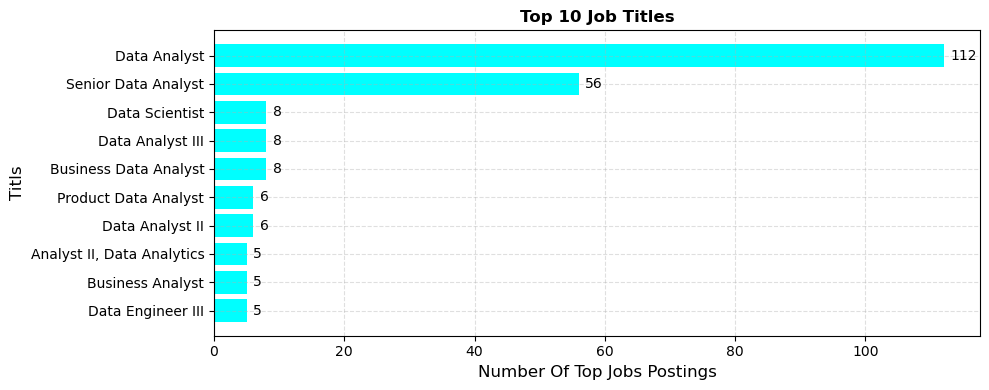

In [57]:
fig , ax = plt.subplots(figsize=(10 , 4))
ax.barh(top_titles.index , top_titles.values , color="cyan"  )
ax.set_title("Top 10 Job Titles" , fontsize=12 , weight="bold")
ax.set_xlabel("Number Of Top Jobs Postings" , fontsize=12) 
ax.set_ylabel("Titls" , fontsize=12)

for index , value in enumerate(top_titles.values):
    ax.text(value+1 , index , str(value) , va="center")    

fig.tight_layout()
ax.invert_yaxis()
ax.grid(linestyle="--" , alpha=0.4)

plt.show()

**Why this chart?**

A horizontal bar chart was chosen because it clearly compares the frequencies of the most common job titles.


---

### Top Job locations (Horizontal Bar Chart)

In [58]:
most_locations = Job_Postings["location"].value_counts().head(10)

In [59]:
most_locations

location
Remote                  332
United States           324
Denver, CO               42
Oklahoma City, OK        33
Bentonville, AR          28
Kansas City, MO          24
Jefferson City, MO       24
Aurora, CO               18
Colorado Springs, CO     16
Springfield, MO          12
Name: count, dtype: int64

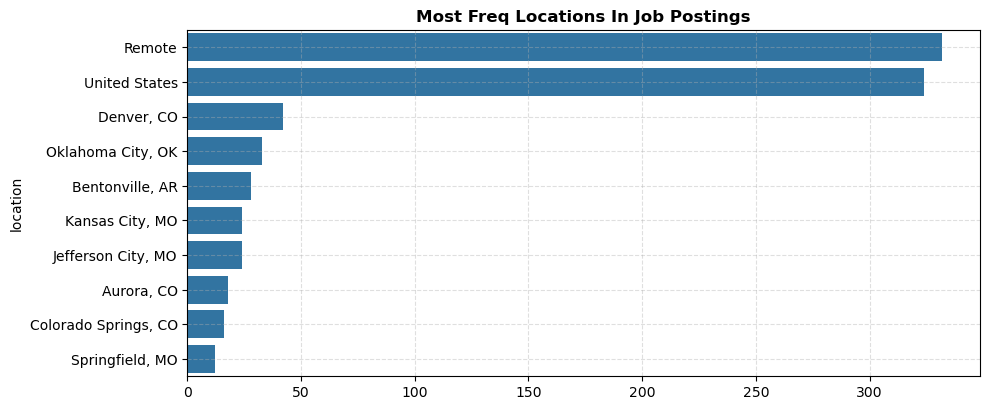

In [60]:
fig,ax = plt.subplots(figsize=(10,4))
sns.barplot(x= most_locations.values , y=most_locations.index )
fig.tight_layout()
ax.set_title("Most Freq Locations In Job Postings" , weight="bold")
ax.grid(linestyle="--" , alpha=0.4)
plt.show()

**Why this chart?**

A horizontal bar chart was chosen because it clearly compares the frequencies of the most common job locations.


---

### Comparison Between Remote and On-Site Jobs (countplot)

In [61]:
most_work_type = Job_Postings["work_type"].value_counts()

In [62]:
most_work_type

work_type
On-site    667
Remote     332
Name: count, dtype: int64

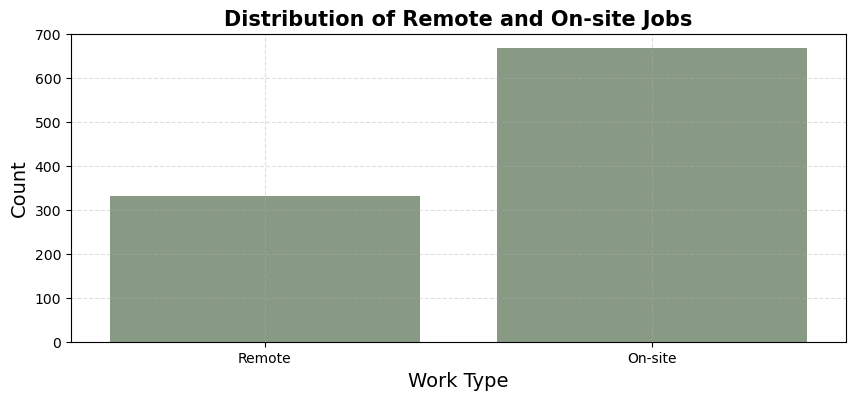

In [63]:
fig,ax = plt.subplots(figsize=(10,4))
sns.countplot(data = Job_Postings , x="work_type", color = "#859E80")
ax.set_xlabel("Work Type" , fontsize=14 , ha = "center")
ax.set_ylabel("Count" , fontsize=14 , ha = "center")
ax.grid(linestyle="--" , alpha=0.4)
ax.set_title("Distribution of Remote and On-site Jobs",fontsize=15,weight="bold")
plt.show()

In [64]:
Job_Postings.shape

(999, 23)

**Why this chart?**

A countplot  was chosen because it clearly compares Between Remote And On-Site Jobs.


---

### Top Job Postings Companies (Horizontal Bar Chart)

In [65]:
Job_Postings.head()

,title,company_name,location,via,description,job_id,thumbnail,posted_at,schedule_type,search_term,date_time,search_location,salary_pay,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens,work_type,skills_count,salary_category
0,Data Analyst,Meta,Remote,via LinkedIn,In the intersection of compliance and analytic...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,15 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,101K–143K,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"[tableau, r, python, sql]",Remote,4,Premium Salary
1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,12 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],On-site,0,Unknown
2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,Unknown,18 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[sql],On-site,1,Unknown
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Remote,via Upwork,Enthusiastic Data Analyst for processing sales...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,Unknown,12 hours ago,Contractor,data analyst,2023-08-04 03:00:13.797776,United States,15–25,20.0,15.0,25.0,20.0,NaN,41600.0,"[powerpoint, excel, power_bi]",Remote,3,Low Salary
4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Contractor,data analyst,2023-08-04 03:00:13.797776,United States,90K–110K,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"[powerpoint, excel, outlook, word]",On-site,4,High Salary


In [66]:
top_companies = Job_Postings["company_name"].value_counts().head(10)
top_companies

company_name
Upwork                               66
Walmart                              64
vmysmartpros                         59
MYSMARTPROS                          17
Sam's Club                           13
Leidos                                9
Talentify.io                          8
Centene Corporation                   8
Saint Louis County Clerks Office      8
Discover Financial Services, Inc.     7
Name: count, dtype: int64

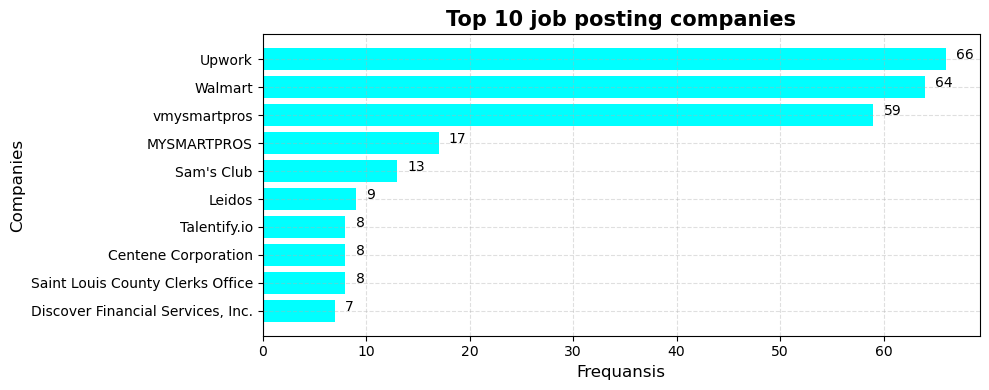

In [67]:
fig,ax = plt.subplots(figsize=(10 , 4))
ax.barh(top_companies.index , top_companies.values , color="cyan" )
ax.set_title("Top 10 job posting companies" , fontsize=15 , weight="bold")
ax.set_xlabel("Frequansis" , fontsize = 12)
ax.set_ylabel("Companies" , fontsize = 12)
ax.grid(linestyle="--" , alpha=0.4)
ax.invert_yaxis()
fig.tight_layout()
for i , value in enumerate(top_companies.values):
    ax.text(value+1 ,i , str(value))
plt.show()

**Why this chart?**

A horizontal bar chart was chosen because it clearly compares the frequencies of the most Companies Are Postings Jobs.


---

### Compare Between Remote And On-site Jobs Based On Salary(box plot)

In [68]:
clear_salary = Job_Postings.copy()


Clear Salary (Drop Missing Values)

In [69]:
clear_salary = clear_salary.dropna(subset=["salary_standardized"])

In [70]:
clear_salary["work_type"].value_counts()

work_type
Remote     49
On-site    42
Name: count, dtype: int64

**Interactive Box Plot**

In [71]:

fig = px.box(clear_salary , x="work_type" , y="salary_standardized" , title="Compare Between Remote Salary And On Site Salary" , color="work_type")
fig.show()


"""
        -The plot shows that the salary of remote jobs more greater than the salary of on site jobs 
        -On site salary has outliers this meaning that some on site jobs has a more larger salary rather than other

"""

'\n        -The plot shows that the salary of remote jobs more greater than the salary of on site jobs \n        -On site salary has outliers this meaning that some on site jobs has a more larger salary rather than other\n\n'

**Why this chart?**

A Box Plot was chosen because it clearly compares Between Remot And On-site Jobs Based On Salary.

Show a relationship between two numeric variables 



---

### Top Skills Required(Horizontal Bar)

In [72]:
row = Job_Postings["description_tokens"].iloc[0]

print(row)
print(type(row))
print(type(row[0]))

['tableau', 'r', 'python', 'sql']
<class 'list'>
<class 'str'>


In [73]:
Job_Postings.head()

,title,company_name,location,via,description,job_id,thumbnail,posted_at,schedule_type,search_term,date_time,search_location,salary_pay,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens,work_type,skills_count,salary_category
0,Data Analyst,Meta,Remote,via LinkedIn,In the intersection of compliance and analytic...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,15 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,101K–143K,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"[tableau, r, python, sql]",Remote,4,Premium Salary
1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,12 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],On-site,0,Unknown
2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,Unknown,18 hours ago,Full-time,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[sql],On-site,1,Unknown
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Remote,via Upwork,Enthusiastic Data Analyst for processing sales...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,Unknown,12 hours ago,Contractor,data analyst,2023-08-04 03:00:13.797776,United States,15–25,20.0,15.0,25.0,20.0,NaN,41600.0,"[powerpoint, excel, power_bi]",Remote,3,Low Salary
4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Contractor,data analyst,2023-08-04 03:00:13.797776,United States,90K–110K,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"[powerpoint, excel, outlook, word]",On-site,4,High Salary


In [74]:
freq_skills_list = []
for row in Job_Postings["description_tokens"]:
    if len(row) > 0:
        freq_skills_list.extend(row)

In [75]:
# freq_skills_list

In [76]:
freq_skills_series = pd.Series(freq_skills_list)

In [77]:
# freq_skills_series

In [78]:
tob_skills = freq_skills_series.value_counts().head(10)

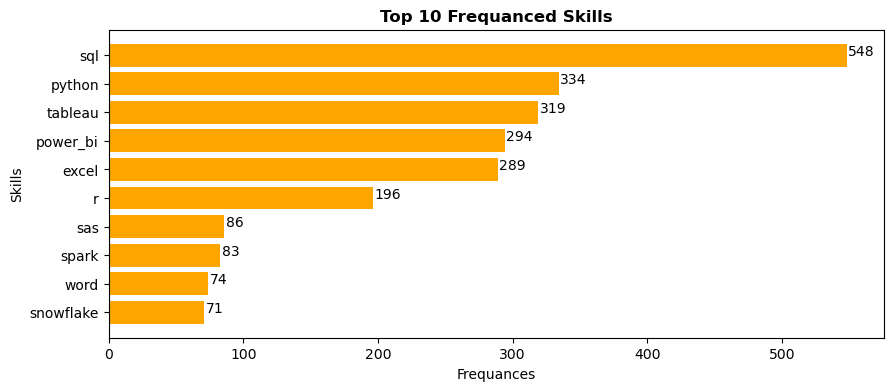

In [79]:
# ------- most skills frequanced --------
fig, ax = plt.subplots(figsize=(10,4))
plt.barh(tob_skills.index, tob_skills.values , color="Orange")
ax.set_title("Top 10 Frequanced Skills" , weight="bold" )
ax.set_xlabel("Frequances")
ax.set_ylabel("Skills")
ax.invert_yaxis()
for i , value in enumerate(tob_skills.values):
    ax.text(value+1 , i , str(value))
plt.show()

**Why this chart?**

A horizontal bar chart was chosen because it clearly compares the frequencies of the most skills required.


---

### Number Of Skills VS Salary(regplot)

' \n        Do jobs that require more skills offer higher salaries?\n\n'

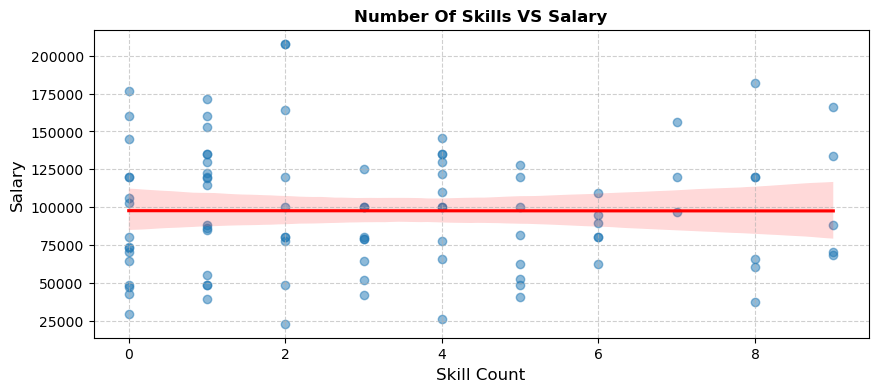

In [ ]:
fig,ax = plt.subplots(figsize=(10,4))
sns.regplot(
    data=Job_Postings,
    x="skills_count",
    y="salary_standardized",
    line_kws=({"color": "red"}),
    scatter_kws=({"alpha" : 0.5})
    )
ax.set_xlabel("Skill Count" , fontsize=12)
ax.set_ylabel("Salary" , fontsize=12)

ax.grid(linestyle="--" , alpha=0.6)
ax.set_title("Number Of Skills VS Salary" , weight="bold")

""" 
    Do jobs that require more skills offer higher salaries?

"""

**Why this chart?**

A regplot was chosen لاecause it clarifies the relationship between number of skills required and salary.

## Key Findings

- Data Analyst was the most common job title among the analyzed postings, followed by Senior Data Analyst.
- SQL And Pytho nwere the most frequently requested technical skills, highlighting their importance in the current data analyst job market.
- On-site positions dominated the dataset, accounting for **66.8%** of all analyzed job postings, while **33.2%** were remote positions.
- Salary information was unavailable for a large number of job postings, limiting the scope of salary-related analysis.
- Some technical skills, such as SQL and Python, frequently appeared together, indicating that employers often require multiple complementary skills.
- A small number of companies and locations accounted for a significant share of the available job postings, suggesting higher hiring demand in those areas.


### Save Cleand Data

In [81]:
# Job_Postings.to_csv("cleaned_job_postings.csv" , index = False)